# Redução de Dimensionalidade de Imagens para Redes Neurais

Este projeto implementa, em Python, o processo de redução de dimensionalidade de uma imagem colorida por meio de duas etapas:

1. Conversão da imagem colorida para tons de cinza;
2. Conversão da imagem em tons de cinza para uma imagem binarizada em preto e branco.

A implementação das transformações será realizada manualmente, sem utilizar funções prontas de bibliotecas específicas para conversão de imagens.

O objetivo é compreender como uma imagem colorida, inicialmente representada por três canais de cor — vermelho, verde e azul (RGB) — pode ser transformada em representações mais simples, reduzindo a quantidade de informação necessária para representar cada pixel.

### Importação das bibliotecas

Será utilizada a biblioteca Pillow apenas para abrir, manipular e salvar o arquivo da imagem. Já a biblioteca matplotlib, será utilizada apenas para visualizar os resultados.

In [16]:
#Importando as bibliotecas

from PIL import Image
import matplotlib.pyplot as plt

In [17]:
#Upload da imagem

from google.colab import files
uploaded = files.upload()

Saving flor.jpg to flor (2).jpg


In [18]:
#Carregando a imagem

flor = list(uploaded.keys())[0]
imagem_colorida = Image.open(flor)
imagem_colorida = imagem_colorida.convert("RGB")

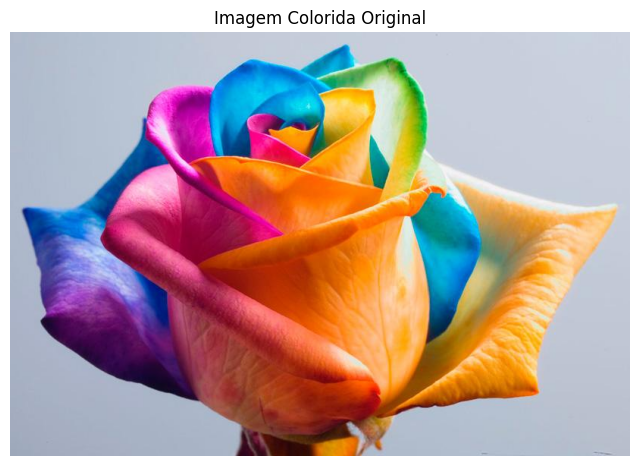

In [19]:
#Visualizando a imagem

plt.figure(figsize=(8, 6))

plt.imshow(imagem_colorida)
plt.axis("off")
plt.title("Imagem Colorida Original")

plt.show()

In [20]:
#Verificando informações relevantes

print("Dimensões da imagem:", imagem_colorida.size)
print("Modo da imagem:", imagem_colorida.mode)

Dimensões da imagem: (818, 560)
Modo da imagem: RGB


Considerando que a imagem tem dimensões 818 x 560 pixels, ela possui 458.080 pixels. Como cada pixel possui três valores (RGB), temos no total uma imagem com 1.374.240 pixels.

Depois da conversão para tons de cinza, a mesma imagem terá 458.080 x 1 = 458.080 valores de intensidade.

Essa é a ideia da redução de dimensionalidade nesse contexto.

## Criando nossa função de conversão para tons de cinza

Uma fórmula simples e bastante utilizada para a conversão é:

***Gray=0.299R+0.587G+0.114B***

Essa fórmula considera a sensibilidade do olho humano a cada cor:
- O olho humano é mais sensível ao verde (G);
- Depois ao vermelho (R);
- E menos ao azul (B).

In [23]:
#Função de conversão

def converter_para_cinza(imagem):
  largura, altura = imagem.size
  imagem_cinza = Image.new("L", (largura, altura))

  pixels_originais = imagem.load()
  pixels_cinza = imagem_cinza.load()

  for y in range(altura):
    for x in range(largura):

      r, g, b = pixels_originais[x, y]

      valor_cinza = int(
        0.299 * r + 0.587 * g + 0.114 * b
      )

      pixels_cinza[x, y] = valor_cinza

  return imagem_cinza

imagem_cinza = converter_para_cinza(imagem_colorida)

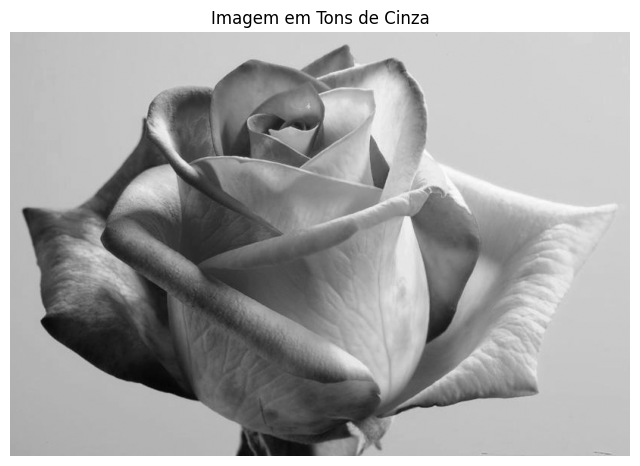

In [24]:
#Visualizando a imagem

plt.figure(figsize=(8, 6))

plt.imshow(imagem_cinza, cmap="gray")
plt.axis("off")
plt.title("Imagem em Tons de Cinza")

plt.show()

Para comprovar que a imagem realmente está usando valores entre 0 e 255, podemos verificar da seguinte forma:

In [25]:
#Verificando os valores da imagem em cinza

pixels_cinza = list(imagem_cinza.getdata())

print("Menor valor encontrado:", min(pixels_cinza))
print("Maior valor encontrado:", max(pixels_cinza))

Menor valor encontrado: 5
Maior valor encontrado: 249


##Criando nossa função de Binarização (Preto e Branco)

Nessa próxima etapa, vamos:

1. definir o limiar;
2. percorrer todos os pixels;
3. comparar cada valor com o limiar;
4. transformar o pixel em 0 ou 255;
5. visualizar o resultado final;
6. testar diferentes valores de limiar para observar o impacto na imagem.



In [47]:
#Criando uma função que recebe a imagem em tons de cinza e um valor de limiar

def binarizar(imagem_cinza, limiar=127):

  largura, altura = imagem_cinza.size
  imagem_binaria = Image.new("L", (largura, altura))

  pixels_cinza = imagem_cinza.load()
  pixels_binarios = imagem_binaria.load()

  for y in range (altura):
    for x in range(largura):

      valor_pixel = pixels_cinza[x, y]

      if valor_pixel >= limiar:
        pixels_binarios[x, y] = 255
      else:
        pixels_binarios[x, y] = 0

  return imagem_binaria

imagem_binaria = binarizar(imagem_cinza)

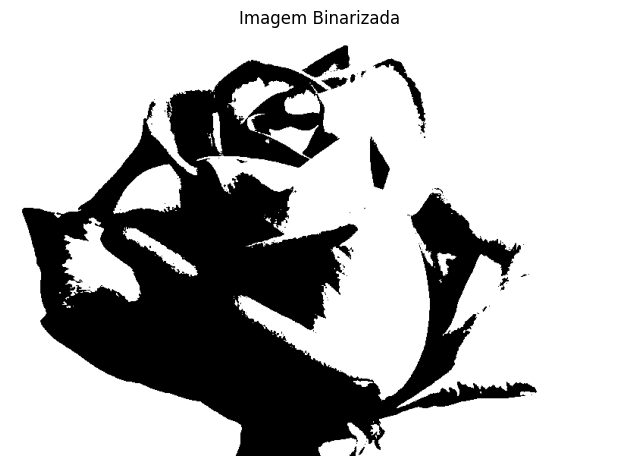

In [48]:
#Visualizando a imagem

plt.figure(figsize=(8, 6))

plt.imshow(imagem_binaria, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Imagem Binarizada")

plt.show()

O limiar foi definido em 127, um valor aproximadamente central na escala de intensidade dos pixels da imagem em tons de cinza, que apresentou valores entre 5 e 249. No entanto, esse não é um valor obrigatório, pois o limiar pode ser ajustado de acordo com as características da imagem e o objetivo da aplicação.

Ao testar valores de limiar maiores, a imagem apresentou uma maior quantidade de pixels classificados como pretos. Por outro lado, valores de limiar menores resultaram em uma maior quantidade de pixels classificados como brancos.

Portanto, o valor 127 foi utilizado como referência para fins didáticos. Em aplicações práticas, a escolha do limiar pode depender das características da imagem e do resultado desejado.

Para comprovar que a imagem realmente está usando apenas dois valores por pixel (0 ou 255), podemos verificar da seguinte forma:

In [57]:
pixels_binarios = list(imagem_binaria.getdata())

print("Menor valor encontrado:", min(pixels_binarios))
print("Maior valor encontrado:", max(pixels_binarios))
print("Valores únicos:", set(pixels_binarios))

Menor valor encontrado: 0
Maior valor encontrado: 255
Valores únicos: {0, 255}


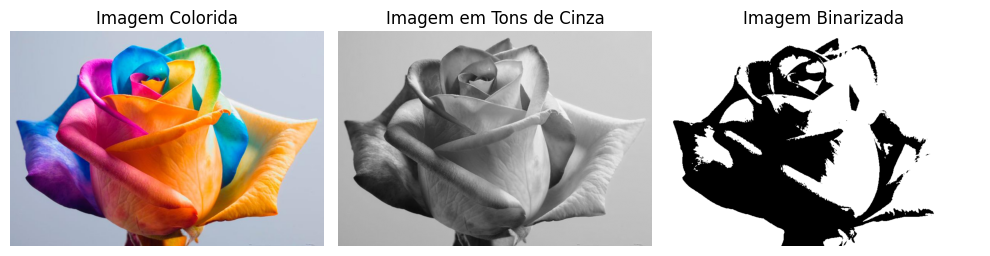

In [56]:
#Comparação visual das três imagens

fig, axes = plt.subplots(1, 3, figsize=(10, 6))

axes[0].imshow(imagem_colorida)
axes[0].set_title("Imagem Colorida")

axes[1].imshow(imagem_cinza, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Imagem em Tons de Cinza")

axes[2].imshow(imagem_binaria, cmap="gray", vmin=0, vmax=25)
axes[2].set_title("Imagem Binarizada")

for ax in axes:
  ax.axis("off")

plt.tight_layout()
plt.show()

##Conclusão

Neste desafio, foi implementado o processo de redução da dimensionalidade de uma imagem colorida por meio de duas etapas de transformação.

Inicialmente, a imagem colorida, representada pelo modelo RGB, possuía três valores associados a cada pixel: vermelho (R), verde (G) e azul (B). Por meio da aplicação manual de uma fórmula ponderada, esses três valores foram combinados para gerar um único valor de intensidade entre 0 e 255, resultando em uma imagem em tons de cinza.

Na sequência, foi implementada uma função de binarização utilizando um valor de limiar. Cada pixel da imagem em tons de cinza foi comparado com esse limiar e classificado como preto (0) ou branco (255). Dessa forma, a imagem final passou a apresentar somente dois valores possíveis de intensidade.

Também foi possível observar que a escolha do limiar influencia diretamente o resultado da binarização. Valores de limiar menores tendem a classificar uma maior quantidade de pixels como brancos, enquanto valores maiores tendem a classificar uma maior quantidade de pixels como pretos.

O desenvolvimento deste projeto permitiu compreender, na prática, como uma imagem pode ter sua representação simplificada, reduzindo a quantidade de informações necessárias para representar seus pixels. Esse processo é importante em diversas aplicações de processamento digital de imagens e visão computacional, podendo contribuir para a preparação de dados utilizados em sistemas baseados em redes neurais.